In [1]:
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import os
while not os.path.isdir('.git'):
    os.chdir('../..')

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

fig_width = 11.27

In [2]:
idxs = np.arange(0, 20)

In [51]:
def read_weights(carrier = 1000, offset = 5, strength = 0.9, initial_weight = 0.1):
    if carrier is None:
        filename = f"noTI_{initial_weight}"
    else:
        filename = f"{carrier}_{offset}_{strength}_{initial_weight}"

    synapses = [f"Synapse{i}" for i in range(10)]
    weights = []
    time = []
    for idx in idxs:
        weights_idx = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance/ltp/{filename}/synapse_weights.csv", index_col = 0)

        weights.append(weights_idx[synapses].mean(axis = 1))

        time = weights_idx.Time

    weights = np.vstack(weights)

    return (time, weights)

In [52]:
initial_weight = 0.1
carrier = 1000

time_5, weights_5 = read_weights(carrier = carrier, offset = 5, strength = 0.9, initial_weight = initial_weight)
time_130, weights_130 = read_weights(carrier = carrier, offset = 130, strength = 0.9, initial_weight = initial_weight)
time_0, weights_0 = read_weights(carrier = carrier, offset = 0, strength = 0.1, initial_weight = initial_weight)

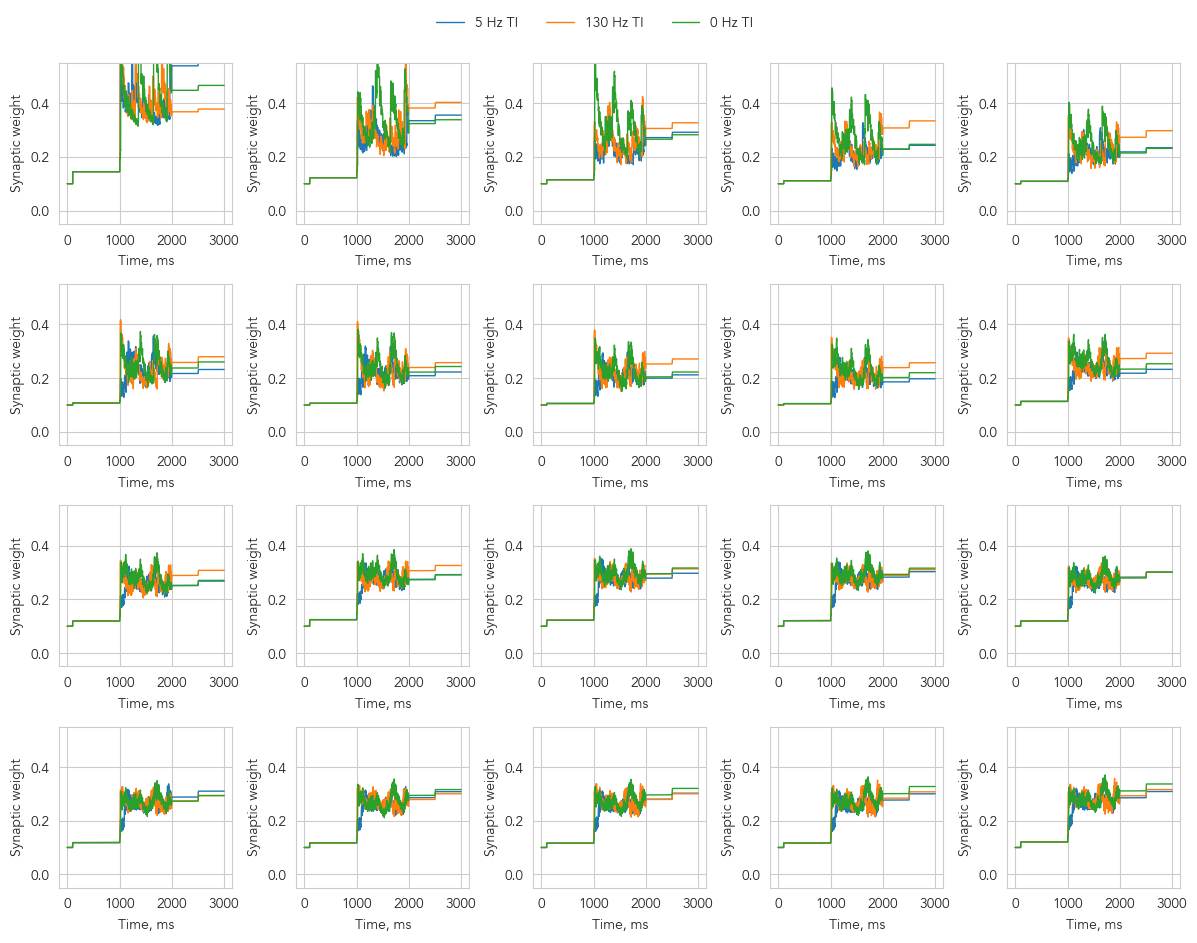

In [72]:
fig, axs = plt.subplots(nrows = 4, ncols = 5, figsize = (12, 9))
axs = axs.flatten()

for i, ax in enumerate(axs):
    ax.plot(
        time_5,
        weights_5[0:(i + 1)].mean(axis = 0),
        linewidth = 1,
        label = "5 Hz TI" if i == 0 else ""
    )

    ax.plot(
        time_130,
        weights_130[0:(i + 1)].mean(axis = 0),
        linewidth = 1,
        label = "130 Hz TI" if i == 0 else ""
    )

    ax.plot(
        time_0,
        weights_0[0:(i + 1)].mean(axis = 0),
        linewidth = 1,
        label = "0 Hz TI" if i == 0 else ""
    )

    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Synaptic weight")
    ax.set_ylim(-0.05, 0.55)

plt.tight_layout()
fig.legend(loc = "upper center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, 1.05))
plt.show()

Mean synaptic weights. Continuously combining results from multiple configurations (1:1, 1:2, 1:3, etc.). So seems that carrier has a large effect on some synaptic configurations which then jump the average to be higher than 5 Hz and 130 Hz TI. In general, this is not a consistent result. The weights are all over the place.